### Sharma et al. (2021) – Co-Hydrothermal liquefaction of lignocellulosic Biomass

**Paper:** Co-Hydrothermal Liquefaction of Lignocellulosic Biomass in Supercritical Water  
**DOI:** 10.3390/en14061708  
**Journal:** Energies 2021, 14, 1708

#### Overview
This notebook ingests experimental data from the Sharma 2021 study on catalytic hydrothermal liquefaction (HTL) of lignocellulosic biomass mixtures. The paper investigates:
- Single feedstocks: wheat straw (WS), eucalyptus (EU), pinewood (PW)
- Binary and ternary mixtures: WS+EU, EU+PW, PW+WS, WS+EU+PW
- HTL at 400°C, 15 min residence time, 20 wt% initial concentration, K₂CO₃ catalyst
- Bio-oil and biochar yields, composition (C/H/O/N), heating values, and energy recovery
- Carbon recovery distribution to bio-oil, char, aqueous, and gas phases

#### Notebook Structure
1. **Helper functions**: Family classification and data ingestion utilities
2. **Data tables**: Feed composition, bio-oil properties, biochar properties from Tables 1–4
3. **Yield calculation**: Back-calculate mass yields from reported energy recovery percentages
4. **Carbon recovery integration**: Merge Figure 6 carbon distribution data with quality checks
5. **Visualization**: Compare reported vs. calculated carbon recovery
6. **Family normalization**: Standardize feedstock family classification
7. **Quality assurance**: Energy/carbon balance checks and envelope plots
8. **Final output**: CSV export for master dataset integration

In [42]:
def family_for_sharma(feed: str) -> str:
    s = (feed or "").lower()
    is_ws = ("wheat" in s) or ("straw" in s) or ("ws" in s)
    is_eu = ("eucalyptus" in s) or ("eu" in s)
    is_pw = ("pine" in s) or ("pinewood" in s) or ("pw" in s)

    if (is_ws + is_eu + is_pw) >= 2:
        herb = is_ws
        woody = is_eu or is_pw
        if herb and woody:
            return "Mixed Biomass / Herbaceous+Woody"
        if is_eu and is_pw:
            return "Woody Biomass / Mixed (Hardwood+Softwood)"
        return "Mixed Biomass"

    if is_ws: return "Agricultural Residues"
    if is_eu: return "Woody Biomass / Hardwood"
    if is_pw: return "Woody Biomass / Softwood"

    if "wood" in s or "woody" in s: return "Woody Biomass / Unspecified"
    return "Unspecified"


In [43]:
import pandas as pd, numpy as np, json
from pathlib import Path

title="Co-Hydrothermal Liquefaction of Lignocellulosic Biomass in Supercritical Water"
doi = "10.3390/en14061708"
prov = "Sharma et al. (2021) Energies 14, 1708"
ref_key = "Sharma_2021_Energies"
publisher = "MDPI"
year = 2021

def _oc(C,H,O):
    if pd.isna(C) or C<=0 or pd.isna(O): return np.nan
    return round((O/16.0)/(C/12.01), 3)

def _hc(C,H,O):
    if pd.isna(C) or C<=0 or pd.isna(H): return np.nan
    return round((H/1.008)/(C/12.01), 3)

def _upsert(df, row, keys=("DOI","Feedstock","T","t","IC","Catalyst")):
    if df.empty:
        return pd.DataFrame([row], columns=row.keys())
    mask = pd.Series(True, index=df.index)
    for k in keys:
        mask &= (df[k] == row.get(k))
    if mask.any():
        i = df.index[mask][0]
        for k,v in row.items():
            if k in df.columns:
                df.at[i,k] = v
        return df
    else:
        return pd.concat([df, pd.DataFrame([row])], ignore_index=True)

# --- Process constants (paper: 400 °C, 15 min, IC=0.25 (20 wt% solids), K2CO3) ---
PROC = dict(
    Process_type="Hydrothermal",
    Process_subtype="Catalytic",
    T=400.0, t=15.0, IC=0.25, Water_Biomass_ratio=4.0,
    Pressure="initial 1 MPa N2; peak 30–32 MPa; autogenic",
    Solvent_or_medium="Water",
    Reactor=None,
    Separation_method=None,
    Yield_basis="wt% daf",
    Catalyst="K2CO3",
    Catalyst_Biomass_ratio=np.nan
)

# --- Feed composition & HHV of FEED (Tables 1–2; elemental = daf) ---
FEED = {
    "Wheat straw (WS)"      : dict(Cellulose_pct=37.9, Hemicellulose_pct=26.8, Lignin=18.3, Ash=6.2,
                                   C=42.15, H=6.21, N=0.82, O=50.82, HHV_input=16.53),
    "Eucalyptus (EU)"       : dict(Cellulose_pct=43.2, Hemicellulose_pct=22.5, Lignin=25.0, Ash=1.6,
                                   C=47.85, H=5.81, N=0.10, O=46.23, HHV_input=18.14),
    "Pinewood (PW)"         : dict(Cellulose_pct=43.6, Hemicellulose_pct=24.9, Lignin=25.6, Ash=0.7,
                                   C=49.90, H=6.30, N=0.30, O=42.80, HHV_input=19.50),
    "WS+EU"                 : dict(Cellulose_pct=np.nan, Hemicellulose_pct=np.nan, Lignin=np.nan, Ash=4.04,
                                   C=45.00, H=6.01, N=0.46, O=48.53, HHV_input=17.34),
    "EU+PW"                 : dict(Cellulose_pct=np.nan, Hemicellulose_pct=np.nan, Lignin=np.nan, Ash=0.87,
                                   C=48.88, H=6.06, N=0.20, O=44.52, HHV_input=18.82),
    "PW+WS"                 : dict(Cellulose_pct=np.nan, Hemicellulose_pct=np.nan, Lignin=np.nan, Ash=3.76,
                                   C=46.03, H=6.26, N=0.56, O=46.81, HHV_input=18.02),
    "WS+EU+PW"              : dict(Cellulose_pct=np.nan, Hemicellulose_pct=np.nan, Lignin=np.nan, Ash=2.89,
                                   C=46.63, H=6.11, N=0.41, O=46.62, HHV_input=18.06),
}

# --- Bio-crude properties & ER_oil% (Table 3; elemental = daf) ---
OIL = {
    "Wheat straw (WS)" : dict(
        C_biooil=73.07,
        H_biooil=8.01,
        N_biooil=1.64,
        O_biooil=17.28,
        H_C=1.32,
        O_C=0.17,
        HHV_biooil=35.50,
        ER_pct=47.25,
    ),
    "Eucalyptus (EU)"  : dict(
        C_biooil=74.73,
        H_biooil=7.76,
        N_biooil=0.93,
        O_biooil=16.58,
        H_C=1.24,
        O_C=0.16,
        HHV_biooil=35.79,
        ER_pct=57.22,
    ),
    "Pinewood (PW)"    : dict(
        C_biooil=75.86,
        H_biooil=7.98,
        N_biooil=1.31,
        O_biooil=14.86,
        H_C=1.30,
        O_C=0.16,
        HHV_biooil=33.66,
        ER_pct=46.61,
    ),
    "WS+EU"            : dict(
        C_biooil=83.27,
        H_biooil=8.41,
        N_biooil=1.05,
        O_biooil=7.18,
        H_C=1.23,
        O_C=0.06,
        HHV_biooil=39.15,
        ER_pct=36.13,
    ),
    "EU+PW"            : dict(
        C_biooil=82.07,
        H_biooil=8.12,
        N_biooil=1.06,
        O_biooil=8.76,
        H_C=1.19,
        O_C=0.08,
        HHV_biooil=37.49,
        ER_pct=29.88,
    ),
    "PW+WS"            : dict(
        C_biooil=77.70,
        H_biooil=7.64,
        N_biooil=0.83,
        O_biooil=13.84,
        H_C=1.21,
        O_C=0.16,
        HHV_biooil=33.67,
        ER_pct=38.39,
    ),
    "WS+EU+PW"         : dict(
        C_biooil=80.90,
        H_biooil=8.38,
        N_biooil=0.70,
        O_biooil=10.02,
        H_C=1.26,
        O_C=0.09,
        HHV_biooil=37.58,
        ER_pct=39.55,
    ),
}

# --- Solid (char) properties & ER_char% (Table 4; elemental = daf) ---
CHAR = {
    "Wheat straw (WS)" : dict(
        C_biochar=54.53,
        H_biochar=2.76,
        N_biochar=1.12,
        O_biochar=41.59,
        H_C=0.61,
        O_C=0.57,
        HHV_biochar=25.79,
        ERHC_pct=15.60,
    ),
    "Eucalyptus (EU)"  : dict(
        C_biochar=66.02,
        H_biochar=3.46,
        N_biochar=0.13,
        O_biochar=30.39,
        H_C=0.62,
        O_C=0.34,
        HHV_biochar=29.48,
        ERHC_pct=19.50,
    ),
    "Pinewood (PW)"    : dict(
        C_biochar=66.59,
        H_biochar=3.35,
        N_biochar=0.42,
        O_biochar=29.65,
        H_C=0.60,
        O_C=0.32,
        HHV_biochar=22.81,
        ERHC_pct=15.21,
    ),
    "WS+EU"            : dict(
        C_biochar=53.09,
        H_biochar=2.58,
        N_biochar=0.01,
        O_biochar=44.32,
        H_C=0.58,
        O_C=0.63,
        HHV_biochar=14.63,
        ERHC_pct=9.28,
    ),
    "EU+PW"            : dict(
        C_biochar=67.78,
        H_biochar=3.16,
        N_biochar=0.20,
        O_biochar=29.27,
        H_C=0.52,
        O_C=0.32,
        HHV_biochar=22.40,
        ERHC_pct=17.85,
    ),
    "PW+WS"            : dict(
        C_biochar=44.49,
        H_biochar=2.64,
        N_biochar=0.31,
        O_biochar=52.57,
        H_C=0.74,
        O_C=0.83,
        HHV_biochar=11.27,
        ERHC_pct=9.79,
    ),
    "WS+EU+PW"         : dict(
        C_biochar=50.09,
        H_biochar=2.97,
        N_biochar=0.39,
        O_biochar=46.56,
        H_C=0.71,
        O_C=0.68,
        HHV_biochar=14.06,
        ERHC_pct=11.68,
    ),
}

# --- Build rows (and compute yields from ER%) ---
rows = []
rows = []
for feed, comp in FEED.items():
    oil = OIL[feed]; ch = CHAR[feed]
    B_Y = oil["ER_pct"] * (comp["HHV_input"] / oil["HHV_biooil"])
    C_Y = ch["ERHC_pct"] * (comp["HHV_input"] / ch["HHV_biochar"])

    extra = {
        "provenance": {"doi": doi, "publisher": publisher, "year": year,
                       "source_tables": ["Table 1","Table 2","Table 3","Table 4"], "source_figures": []},
        "Basis_tags": ["daf"],  # paper uses daf for yields & elemental analyses
        "notes": "Catalyst 2 wt% of slurry (~10 wt% of dry biomass); left Catalyst_Biomass_ratio as NaN.",
        "ER_pct_oil_reported": oil["ER_pct"],
        "Basis_tags": ["daf"],
    }

    row = {
        # core provenance
        "DOI": doi, "Provenance": prov, "Ref": ref_key, "Source_Figure": "Tables 1–4 (reported)",
        # process
        "DOI": doi, "Provenance": prov, "Ref": ref_key, "Source_Figure": "Tables 1–4 (reported)",
        **PROC,
        "Feedstock": feed, "Family": family_for_sharma(feed), "Tier": "Experimental",
        "Lignin": comp.get("Lignin"), "Cellulose_pct": comp.get("Cellulose_pct"),
        "Hemicellulose_pct": comp.get("Hemicellulose_pct"), "Extractives_pct": np.nan,
        "C": comp["C"], "H": comp["H"], "O": comp["O"], "N": comp["N"],
        "S": np.nan, "Ash": comp["Ash"], "O/C": _oc(comp["C"], comp["H"], comp["O"]),
        "H/C": _hc(comp["C"], comp["H"], comp["O"]), "HHV_input": comp["HHV_input"],
        "B_Y": round(B_Y, 2), "C_Y": round(C_Y, 2), "A_Y": np.nan, "G_Y": np.nan, "GW_Y": np.nan,
        "HHV_biooil": oil["HHV_biooil"], "C_biooil": oil["C_biooil"], "H_biooil": oil["H_biooil"], "N_biooil": oil["N_biooil"], "O_biooil": oil["O_biooil"], "S_biooil": None, "H_C_biooil": oil["H_C"], "O_C_biooil": oil["O_C"],
        "HHV_biochar": ch["HHV_biochar"], "C_biochar": ch["C_biochar"], "H_biochar": ch["H_biochar"], "N_biochar": ch["N_biochar"], "O_biochar": ch["O_biochar"], "S_biochar": None, "H_C_biochar": ch["H_C"], "O_C_biochar": ch["O_C"],
        "E_B": round((B_Y/100.0)*oil["HHV_biooil"], 3),
        "E_H": round((C_Y/100.0)*ch["HHV_biochar"], 3),
        "C_B": round((B_Y/100.0)*(oil["C_biooil"]/100.0), 4),
        "C_H": round((C_Y/100.0)*(ch["C_biochar"]/100.0), 4),
        "Moisture_min": np.nan, "Moisture_max": np.nan,
        "Lignin_Rich": False,
        "extra": json.dumps(extra, ensure_ascii=False)
    }
    rows.append(row)

df = pd.DataFrame(rows)
df["Paper_Title"] = title
# --- Save
out = Path("./CSVs") / f"{ref_key}.csv"
out.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(out, index=False)

print(df[["Feedstock","B_Y","C_Y","E_B","E_H","C_B","C_H"]].to_string(index=False))
# --- Save
# --- Tiny updater (add/change a row later) ---
def update_sharma_row(df, feedstock, updates):

    base_key = dict(DOI=doi, Feedstock=feedstock, T=400.0, t=15.0, IC=0.25, Catalyst="K2CO3")
    row_now = {**{c: np.nan for c in df.columns}, **base_key}
    if not df.empty:
        hit = (df["DOI"]==doi)&(df["Feedstock"]==feedstock)&(df["T"]==400.0)&(df["t"]==15.0)&(df["IC"]==0.25)&(df["Catalyst"]=="K2CO3")
        if hit.any():
            row_now = df[hit].iloc[0].to_dict()
def update_sharma_row(df, feedstock, updates):
    base_key = dict(DOI=doi, Feedstock=feedstock, T=400.0, t=15.0, IC=0.25, Catalyst="K2CO3")
    row_now = {**{c: np.nan for c in df.columns}, **base_key}
    if not df.empty:
        hit = (df["DOI"]==doi)&(df["Feedstock"]==feedstock)&(df["T"]==400.0)&(df["t"]==15.0)&(df["IC"]==0.25)&(df["Catalyst"]=="K2CO3")

       Feedstock   B_Y   C_Y    E_B   E_H    C_B    C_H
Wheat straw (WS) 22.00 10.00  7.810 2.579 0.1608 0.0545
 Eucalyptus (EU) 29.00 12.00 10.380 3.537 0.2167 0.0792
   Pinewood (PW) 27.00 13.00  9.089 2.966 0.2048 0.0866
           WS+EU 16.00 11.00  6.265 1.609 0.1333 0.0584
           EU+PW 15.00 15.00  5.623 3.359 0.1231 0.1017
           PW+WS 20.55 15.65  6.918 1.764 0.1596 0.0696
        WS+EU+PW 19.01 15.00  7.143 2.109 0.1538 0.0751


In [44]:

import pandas as pd, numpy as np, json

def merge_fig6_carbon_recovery(df, cr_map, *, overwrite=False):
    """
    cr_map example (fill with your digitized % values later):
      {
        "Wheat straw (WS)": {"oil": 38.0, "char": 13.0, "aq": 22.0, "gas": 27.0},
        "Eucalyptus (EU)":  {"oil": 45.0, "char": 17.0, "aq": 12.0, "gas": 26.0},
        ...
      }
    overwrite=False -> never replace existing B_Y/C_Y.
    Assumes the Sharma (2021) constant conditions (400°C, 15 min, IC=0.25, K2CO3).
    """
    out = df.copy()
    for feed, cr in cr_map.items():
        hit = (
            (out["Feedstock"] == feed) &
            (out["T"] == 400.0) & (out["t"] == 15.0) &
            (out["IC"] == 0.25) & (out["Catalyst"] == "K2CO3")
        )
        if not hit.any():
            continue
        idx = out.index[hit][0]


        ex = json.loads(out.at[idx, "extra"]) if isinstance(out.at[idx, "extra"], str) else (out.at[idx, "extra"] or {})
        ex.setdefault("provenance", {}).setdefault("source_figures", [])
        if "Fig. 6" not in ex["provenance"]["source_figures"]:
            ex["provenance"]["source_figures"].append("Fig. 6")
        ex["CR_fig6_pct"] = {
            "biooil": cr.get("oil"),
            "char":   cr.get("char"),
            "aq":     cr.get("aq"),
            "gas":    cr.get("gas")
        }
        tot = sum(v for v in ex["CR_fig6_pct"].values() if v is not None)
        if tot is not None:
            ex["CR_fig6_sum_pct"] = round(tot, 2)
            ex["CR_fig6_unassigned_pct"] = round(100.0 - tot, 2)

  
        C_feed = out.at[idx, "C"]                   
        B_Y    = out.at[idx, "B_Y"]
        C_Y    = out.at[idx, "C_Y"]
        C_bo = out.at[idx, "C_biooil"]   
        O_bo = out.at[idx, "O_biooil"]
        H_bo = out.at[idx, "H_biooil"]
        N_bo = out.at[idx, "N_biooil"]

        C_ch = out.at[idx, "C_biochar"]  
        O_ch = out.at[idx, "O_biochar"]
        H_ch = out.at[idx, "H_biochar"]
        N_ch = out.at[idx, "N_biochar"]

        qa = {}
        if pd.notna(B_Y) and pd.notna(C_bo) and pd.notna(C_feed) and C_feed > 0:
            qa["CR_oil_calc_pct"] = round(100.0 * ((B_Y/100.0)*(C_bo/100.0)) / (C_feed/100.0), 2)
            if cr.get("oil") is not None:
                qa["CR_oil_delta_pct"] = round(qa["CR_oil_calc_pct"] - cr["oil"], 2)
        if pd.notna(C_Y) and pd.notna(C_ch) and pd.notna(C_feed) and C_feed > 0:
            qa["CR_char_calc_pct"] = round(100.0 * ((C_Y/100.0)*(C_ch/100.0)) / (C_feed/100.0), 2)
            if cr.get("char") is not None:
                qa["CR_char_delta_pct"] = round(qa["CR_char_calc_pct"] - cr["char"], 2)


        if pd.notna(C_feed) and C_feed > 0:
            if cr.get("aq")  is not None: qa["C_A_kgC_per_kgfeed"]  = round((cr["aq"]/100.0) * (C_feed/100.0), 4)
            if cr.get("gas") is not None: qa["C_G_kgC_per_kgfeed"]  = round((cr["gas"]/100.0) * (C_feed/100.0), 4)

        ex["CR_fig6_QA"] = qa


        if pd.isna(B_Y) and cr.get("oil") is not None and pd.notna(C_bo) and pd.notna(C_feed) and C_bo > 0:
            out.at[idx, "B_Y"] = round(cr["oil"] * (C_feed / C_bo), 2)
        elif overwrite and cr.get("oil") is not None and pd.notna(C_bo) and pd.notna(C_feed) and C_bo > 0:
            out.at[idx, "B_Y"] = round(cr["oil"] * (C_feed / C_bo), 2)

        if pd.isna(C_Y) and cr.get("char") is not None and pd.notna(C_ch) and pd.notna(C_feed) and C_ch > 0:
            out.at[idx, "C_Y"] = round(cr["char"] * (C_feed / C_ch), 2)
        elif overwrite and cr.get("char") is not None and pd.notna(C_ch) and pd.notna(C_feed) and C_ch > 0:
            out.at[idx, "C_Y"] = round(cr["char"] * (C_feed / C_ch), 2)

        out.at[idx, "extra"] = json.dumps(ex)

    return out


In [45]:

FIG6_CR = {
    "Wheat straw (WS)": {"oil": 37.52, "char": 13.26, "aq": 22.20, "gas": 26.90},
    "Eucalyptus (EU)":  {"oil": 45.11, "char": 16.77, "aq": 12.43, "gas": 25.81},
    "Pinewood (PW)":    {"oil": 41.01, "char": 17.86, "aq": 10.49, "gas": 30.52},
    "WS+EU":            {"oil": 29.19, "char": 13.27, "aq": 18.46, "gas": 39.20},
    "EU+PW":            {"oil": 24.85, "char": 20.99, "aq": 12.42, "gas": 41.50},
    "PW+WS":            {"oil": 33.41, "char": 15.08, "aq": 12.43, "gas": 39.20},
    "WS+EU+PW":         {"oil": 33.05, "char": 15.56, "aq": 15.80, "gas": 35.59},
}


df = merge_fig6_carbon_recovery(df, FIG6_CR)   
df.to_csv(out, index=False)

In [46]:
import numpy as np, json
import matplotlib.pyplot as plt

def plot_cr_fig6_comparison(df, which="biooil", order=None):
    """
    which: "biooil" or "char"
    order: optional list of feedstock names to control x-axis order
    Requires: merge_fig6_carbon_recovery(...) already added CR_fig6_* to extra.
    """
    key_rep = "biooil" if which == "biooil" else "char"
    key_calc = "CR_oil_calc_pct" if which == "biooil" else "CR_char_calc_pct"

    labels, reported, calculated = [], [], []
    for _, row in df.iterrows():

        ex = row.get("extra")
        try:
            ex = json.loads(ex) if isinstance(ex, str) else (ex or {})
        except Exception:
            ex = {}

        cr = (ex.get("CR_fig6_pct") or {}).get(key_rep)
        qa = (ex.get("CR_fig6_QA") or {}).get(key_calc)

        if cr is None or qa is None or np.isnan(cr) or np.isnan(qa):
            continue

        labels.append(row["Feedstock"])
        reported.append(float(cr))
        calculated.append(float(qa))

    if not labels:
        print("No rows with CR_fig6 data found. Did you run merge_fig6_carbon_recovery()?")
        return


    if order:
        idx_map = {name:i for i, name in enumerate(labels)}
        keep = [name for name in order if name in idx_map]
        idxs = [idx_map[name] for name in keep]
        labels    = [labels[i]    for i in idxs]
        reported  = [reported[i]  for i in idxs]
        calculated= [calculated[i]for i in idxs]

    x = np.arange(len(labels))
    width = 0.42

    plt.figure(figsize=(10, 4))
    plt.bar(x - width/2, reported,  width, label=f"Reported CR% ({which})")
    plt.bar(x + width/2, calculated, width, label=f"Calc from B_Y & C% ({which})")

    plt.xticks(x, labels, rotation=30, ha="right")
    plt.ylabel("Carbon recovery (%)")
    plt.ylim(0, 100)
    plt.title("Figure 6 check: reported vs. back-calculated carbon recovery")


    for i,(r,c) in enumerate(zip(reported, calculated)):
        plt.text(x[i]-width/2, r+1, f"{r:.1f}", ha="center", va="bottom", fontsize=8)
        plt.text(x[i]+width/2, c+1, f"{c:.1f}", ha="center", va="bottom", fontsize=8)

    plt.legend()
    plt.tight_layout()
    plt.show()


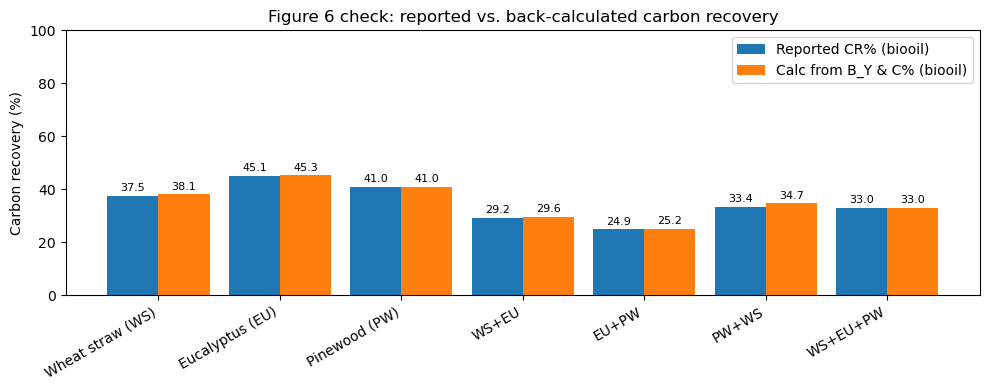

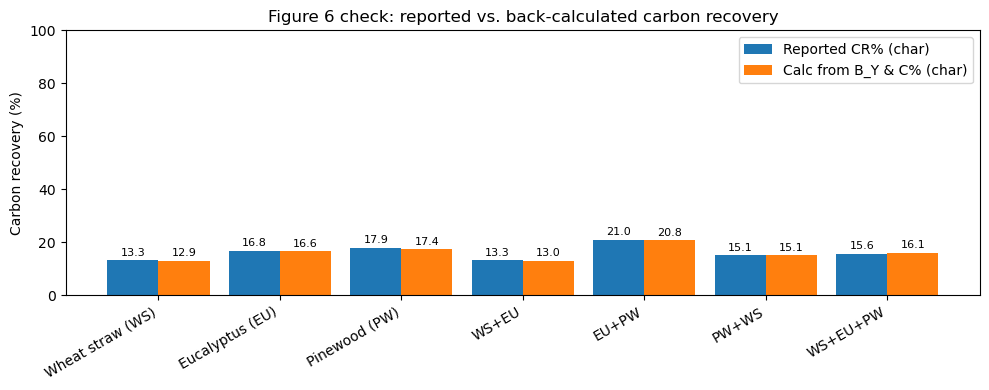

In [47]:
order = ["Wheat straw (WS)","Eucalyptus (EU)","Pinewood (PW)",
         "WS+EU","EU+PW","PW+WS","WS+EU+PW"]

plot_cr_fig6_comparison(df, which="biooil", order=order)
plot_cr_fig6_comparison(df, which="char",   order=order)


In [48]:
print(df)

                  DOI                              Provenance  \
0  10.3390/en14061708  Sharma et al. (2021) Energies 14, 1708   
1  10.3390/en14061708  Sharma et al. (2021) Energies 14, 1708   
2  10.3390/en14061708  Sharma et al. (2021) Energies 14, 1708   
3  10.3390/en14061708  Sharma et al. (2021) Energies 14, 1708   
4  10.3390/en14061708  Sharma et al. (2021) Energies 14, 1708   
5  10.3390/en14061708  Sharma et al. (2021) Energies 14, 1708   
6  10.3390/en14061708  Sharma et al. (2021) Energies 14, 1708   

                    Ref          Source_Figure  Process_type Process_subtype  \
0  Sharma_2021_Energies  Tables 1–4 (reported)  Hydrothermal       Catalytic   
1  Sharma_2021_Energies  Tables 1–4 (reported)  Hydrothermal       Catalytic   
2  Sharma_2021_Energies  Tables 1–4 (reported)  Hydrothermal       Catalytic   
3  Sharma_2021_Energies  Tables 1–4 (reported)  Hydrothermal       Catalytic   
4  Sharma_2021_Energies  Tables 1–4 (reported)  Hydrothermal       Catalytic   

In [49]:

_CANON_FAMILY = {
    "Model Compound",
    "Lignin-rich Streams",
    "Aquatic Biomass",
    "Herbaceous Biomass",
    "Agricultural Residues",
    "Woody Biomass / Softwood",
    "Woody Biomass / Hardwood",
    "Woody Biomass / Unspecified",
    "Mixed Biomass / Herbaceous+Woody",
    "Woody Biomass / Mixed (Hardwood+Softwood)",
    "Mixed Biomass",
}

_HERB_TOK = ["straw","grass","herbaceous","bagasse","stalk","cob","husk","hulls","silage","grain","agricultur"]
_HARD_TOK = ["hardwood","oak","beech","birch","eucalyptus","poplar","willow"]
_SOFT_TOK = ["softwood","pine","spruce","fir","larch","conifer"]
_WOODY_TOK= ["wood","woody","timber","lignocellulosic","ligno-cellulosic","lignocellulose"]

def classify_family(fam_txt: str, feed_txt: str = "") -> str:
    fam = (fam_txt or "").strip()
    feed = (feed_txt or "")
    s = f"{fam} {feed}".lower()

 
    if fam in _CANON_FAMILY:
        return fam

 
    if any(k in s for k in ["model", "pure substrate", "surrogate"]):
        return "Model Compound"
    if any(k in s for k in ["lignin-rich","black liquor","kraft","organosolv","soda lignin","technical lignin","derived","processed"]):
        return "Lignin-rich Streams"
    if any(k in s for k in ["aquatic","algae","seaweed","macroalgae","microalgae","hyacinth"]):
        return "Aquatic Biomass"
    if any(k in s for k in ["herbaceous","forage","poaceae"]):
        return "Herbaceous Biomass"
    if any(k in s for k in _HERB_TOK):
        return "Agricultural Residues"


    is_mix = ("+" in s) or any(k in s for k in ["mix","mixture","blend","co-htl","co htl","co-liquefaction","co processing"])
    has_herb = any(k in s for k in _HERB_TOK)
    has_hard = any(k in s for k in _HARD_TOK)
    has_soft = any(k in s for k in _SOFT_TOK)
    has_woody = any(k in s for k in _WOODY_TOK) or has_hard or has_soft

    if is_mix or (has_herb and has_woody) or (has_hard and has_soft):
        if has_herb and has_woody:
            return "Mixed Biomass / Herbaceous+Woody"
        if has_hard and has_soft:
            return "Woody Biomass / Mixed (Hardwood+Softwood)"
        return "Mixed Biomass"

    if any(k in s for k in _SOFT_TOK):
        return "Woody Biomass / Softwood"
    if any(k in s for k in _HARD_TOK):
        return "Woody Biomass / Hardwood"
    if any(k in s for k in _WOODY_TOK):
        return "Woody Biomass / Unspecified"

    return "Unspecified"

def normalize_family_df(df, inplace=True):
    out = df if inplace else df.copy()
    if "Family" not in out.columns or "Feedstock" not in out.columns:
        return out
    out["Family"] = out.apply(lambda r: classify_family(r.get("Family"), r.get("Feedstock")), axis=1)
    return out


In [50]:
df = normalize_family_df(df.copy(), inplace=False)
mask_en = df["DOI"].astype(str).eq("10.3390/en14061708")

df.loc[mask_en, "Reactor"] = df.loc[mask_en, "Reactor"].fillna(
    "20 mL SS batch reactor; 7 g slurry (20 wt% DM); immersed in 400 °C fluidized sand bath"
)
df.loc[mask_en, "Separation_method"] = df.loc[mask_en, "Separation_method"].fillna(
    "Vent gas → decant aqueous → acetone wash of reactor → vacuum filtration (5–13 μm) → evaporate acetone to recover biocrude"
)
df.loc[mask_en, "Yield_basis"] = df.loc[mask_en, "Yield_basis"].fillna("wt% daf")
df.loc[mask_en, "Catalyst"] = df.loc[mask_en, "Catalyst"].fillna("K2CO3")
df["Process_subtype"] = df["Process_subtype"].fillna("Co-Hydrothermal Liquefaction")


df.loc[mask_en, "Catalyst_Biomass_ratio"] = df.loc[mask_en, "Catalyst_Biomass_ratio"].fillna(0.10)

df.to_csv(out, index=False)


E_H > 25.0 MJ/kg: 0 rows
E_B > 25.0 MJ/kg: 0 rows
B_Y outside [0,100]: 0 rows
C_Y outside [0,100]: 0 rows
C_B > 0.60 (fraction): 0 rows
C_H > 0.65 (fraction): 0 rows
HHV_input < 12 MJ/kg: 0 rows
H/C outside ~[0.8,1.9]: 0 rows
O/C outside ~[0.35,0.95]: 0 rows


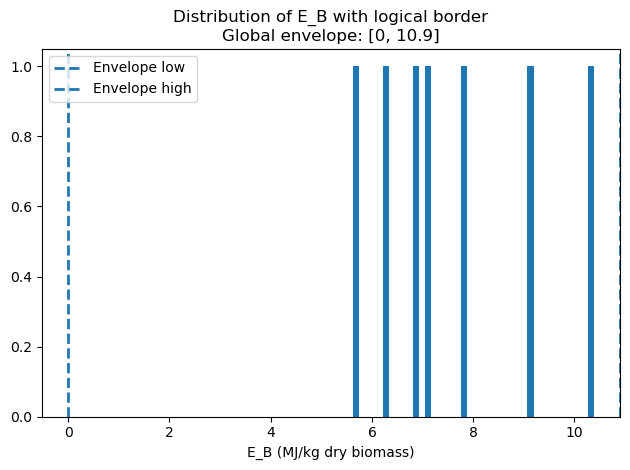

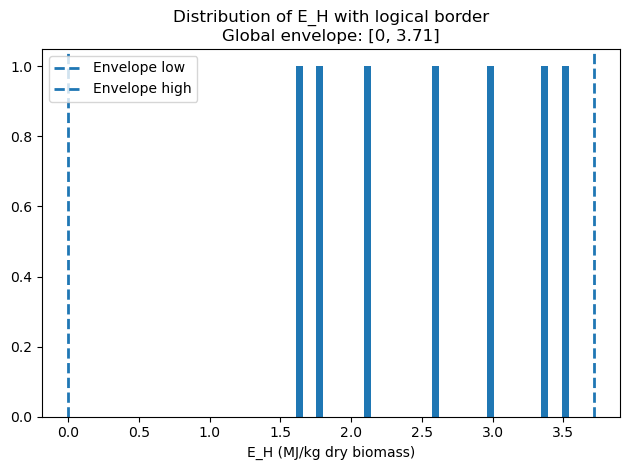

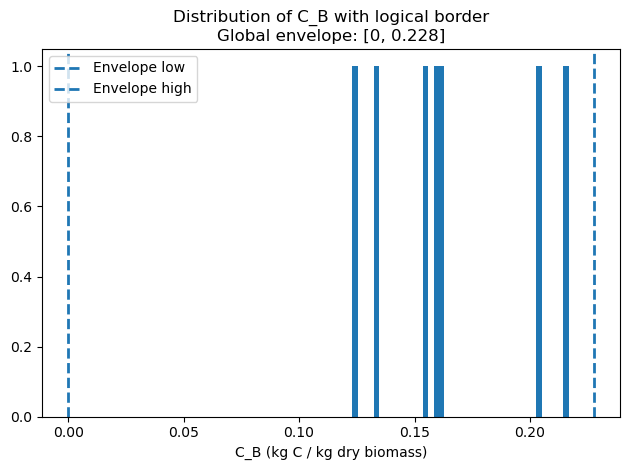

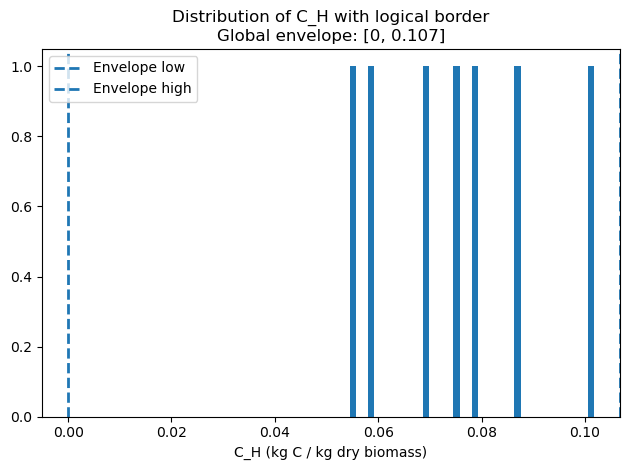

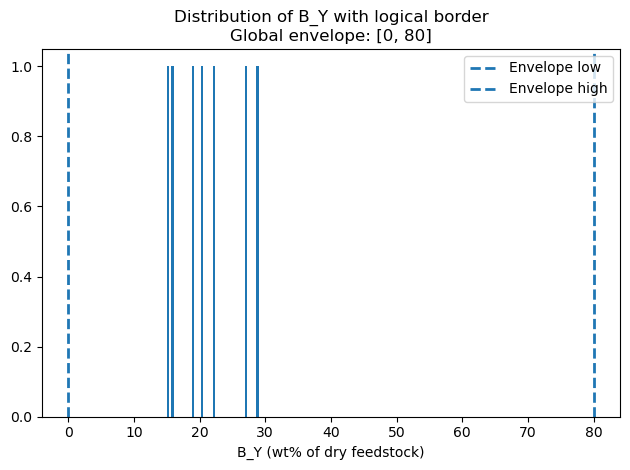

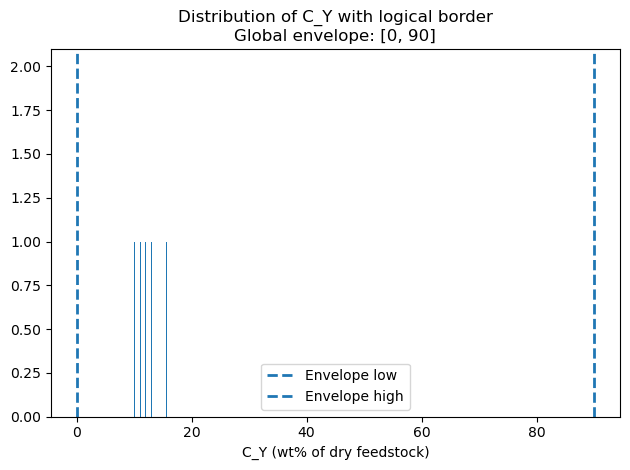

No data to plot for A_Y.
No data to plot for G_Y.


In [51]:
import importlib.util, pathlib, sys

mod_path = pathlib.Path("../../modules/qa_envelopes.py").resolve() 
spec = importlib.util.spec_from_file_location("qa_envelopes", str(mod_path))
qa_envelopes = importlib.util.module_from_spec(spec)
sys.modules["qa_envelopes"] = qa_envelopes
spec.loader.exec_module(qa_envelopes)

qa_envelopes.run_basic_qc(df)
qa_envelopes.plot_energy_carbon_envelopes(df)
qa_envelopes.plot_yield_envelopes(df)